# Final Project - Week 5 Submission
### Data Cleaning and Quality Assessment
#### Due: Tuesday, November 26, 2024 at 11:59 PM





<br>


Building upon your Week 4 dataset selection, this week focuses on data cleaning and quality improvement.

#### Submission Requirements:
- Submit a PDF or Jupyter notebook (.ipynb) containing:
  - All code with outputs visible
  - Clear documentation for data cleaning (Part 5)
    - You can use markdown in Jupyter notebook, or write your final summary in Word/PDF. If you choose Word/PDF, please still submit your notebook/PDF containing the code)<br><br>

    
  
- For individual submission: Include your name in either the filename or within the notebook content
- For team submission: 
  1. Include all team members' names in the notebook content
  2. For team members from different sessions, clearly indicate their session numbers
  3. All team members are required to submit a copy of the assignment

<br>

I encourage you to build upon last week's assignment and complete this week's work in the same Jupyter notebook. Please make sure to clearly label the part numbers. Alternatively, you can paste your work from last week into this notebook so that the data overview from the previous week is visible. This will allow you to refine and improve both weeks' work, making it more organized and cohesive.

### Part 1: Missing Value Analysis
Before we begin working with Python to handle missing values, I’d like to briefly review the methods for handling missing data, as a refresher from your previous statistics courses. In fact, missing values is a vast topic, with many different methods for dealing with them, depending on factors such as sample size, the purpose of the analysis, and the nature of the data. In this assignment, we will focus on practicing several common and straightforward methods using Python to handle missing values. (You can choose any one of the following methods to handle missing values.)
#### 1. Missing Value Assessment

We first need to identify which variables or data points contain missing values. Common markers for missing values include NaN, null, None, or special numeric values (e.g., -9999), and even special symbols like "?" or similar. Sometimes, missing values are also classified by us, for instance, when we encode rare categories like "not sure" or "prefer not to answer" as missing values. Therefore, the first step is to check the dataset for these markers to identify which missing values need to be handled.

*Here is some basic code to check for missing values. You can refer to this or use other methods if preferred.*

In [26]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path to the data directory
data_dir = r'C:/Users/priya/OneDrive/Documents/personal/Data-Historical-Alpaca/2months_tradierdata_json'

# Combine data from all stock symbol folders
all_data = []
for stock_symbol in os.listdir(data_dir):
    symbol_path = os.path.join(data_dir, stock_symbol)
    if os.path.isdir(symbol_path):
        for file in os.listdir(symbol_path):
            file_path = os.path.join(symbol_path, file)
            if file.endswith('.json'):
                df = pd.read_json(file_path)
                df['Symbol'] = stock_symbol  # Add a column for the stock symbol
                all_data.append(df)

# Combine all data into one DataFrame
stock_data = pd.concat(all_data, ignore_index=True)

# 1. Overview of Missing Values
print("Missing Value Overview:")
print(stock_data.isnull().sum())

# 2. Calculate Missing Value Percentage
missing_percentage = (stock_data.isnull().sum() / len(stock_data)) * 100
print("\nPercentage of Missing Values:")
print(missing_percentage)

# 3. Check for Special Markers
# Check for potential missing markers explicitly
missing_markers = [-9999, '?',"", "N/A", "unknown", 0]
for column in stock_data.columns:
    potential_missing = stock_data[column].isin(missing_markers).any()
    if potential_missing:
        print(f"Potential missing markers found in column: {column}")


Missing Value Overview:
time         0
timestamp    0
price        0
open         0
high         0
low          0
close        0
volume       0
vwap         0
Symbol       0
dtype: int64

Percentage of Missing Values:
time         0.0
timestamp    0.0
price        0.0
open         0.0
high         0.0
low          0.0
close        0.0
volume       0.0
vwap         0.0
Symbol       0.0
dtype: float64



**Types of missing data:**

- MCAR (Missing Completely at Random): The missing value has no relationship to any values in the dataset, observed or missing.
   - Example: A survey page is accidentally lost due to wind.<br><br>

  
- MAR (Missing at Random): The missingness of the data is related to observed variables but not to the missing values themselves. In other words, missing data can be predicted based on other available information.
   - Example: In a health survey, younger respondents are more likely to skip questions about income, but the missing income data can be predicted based on the respondent's age.<br><br>
- MNAR (Missing Not at Random): The missingness of the data is related to the missing values themselves. In other words, the reason the data is missing depends on the unobserved value, making the missingness non-random.
   - Example: Respondents with lower incomes are more likely to skip the income question. The missingness is related to the income value itself, making it not random (MNAR).

*Understanding the type of missing data helps in choosing the right handling method. For example, MCAR data can generally be safely deleted, while MAR data may require imputation, and MNAR data might need more customized handling methods.*

### 2. Missing Value Treatment
*I have provided some example code that you can try out, but feel free to use other code to handle the missing values in your dataset as well.* 

- **Deletion**
  
    - Listwise Deletion: This method is used when the missing data is Missing Completely at Random (MCAR) and accounts for less than 5% of the total data. It is commonly applied in regression analysis to avoid the impact of missing values in a single feature from affecting the entire analysis.
      
    - Column Deletion: If a particular feature has a large amount of missing data, such that the feature provides little to no useful information, it may be appropriate to delete that column entirely.<br><br>


- We can also use **simple imputation methods** to handle missing values. Here's when to use each method:
  
   - Mean: When the data is normally distributed.
   - Median: When the data is skewed or contains outliers.
   - Mode: For categorical variables, where the most frequent category is used to fill in missing values.
     
     *Note*: if the proportion of missing data is too high (e.g., >50%), imputation may lead to unreliable results. In such cases, it is better to consider deleting the variable rather than attempting to impute the missing values.

In [30]:
# 4. Imputation Techniques
if stock_data.isnull().sum().sum() > 0:  # If there are missing values
    print("\nHandling Missing Values:")

    # Mean Imputation (for numeric columns, normally distributed data)
    if 'price' in stock_data.columns:
        stock_data['price'] = stock_data['price'].fillna(stock_data['price'].mean())
        print("Filled missing 'price' with mean value.")

    # Median Imputation (for numeric columns with outliers)
    if 'volume' in stock_data.columns:
        stock_data['volume'] = stock_data['volume'].fillna(stock_data['volume'].median())
        print("Filled missing 'volume' with median value.")

    # Mode Imputation (for categorical variables)
    if 'Symbol' in stock_data.columns:
        stock_data['Symbol'] = stock_data['Symbol'].fillna(stock_data['Symbol'].mode()[0])
        print("Filled missing 'Symbol' with mode value.")

    # Forward Fill (for time series data)
    stock_data.fillna(method='ffill', inplace=True)
    print("Forward fill applied to missing values.")

    # Backward Fill (alternative for time series data)
    stock_data.fillna(method='bfill', inplace=True)
    print("Backward fill applied to missing values.")
else:
    print("\nNo missing values detected in the dataset.")

# 5. Display Cleaned Dataset Overview
print("\nCleaned Data Overview:")
print(stock_data.isnull().sum())


No missing values detected in the dataset.

Cleaned Data Overview:
time         0
timestamp    0
price        0
open         0
high         0
low          0
close        0
volume       0
vwap         0
Symbol       0
dtype: int64


- For **time series data**, especially when the positions of missing values are determined by time or sequence, and the values are likely to change little in terms of magnitude, we can use forward fill and backward fill.

  - Forward fill: the missing value is filled with the most recent known value before it. In other words, if a data point is missing at a particular time, we use the value from the previous time point to fill in the missing value.
  - Backward fill: the missing value is filled with the next known value after it. In other words, if a data point is missing at a particular time, we use the value from the next time point to fill in the missing value.

*In addition to the methods mentioned above, there are more complex imputation techniques, such as KNN, multiple imputation, regression, and random forest, that can be used to predict missing values. These methods generally provide more accurate results, especially when the dataset is large and the relationships between variables are complex. However, these methods are more complex, so we will not be practicing them in this project.*

<br>

### Part 2: Outlier Detection and Treatment

Handling outliers also depends on the specific situation. For large datasets, statistical methods like IQR or Z-score can be used for batch processing to detect outliers efficiently. However, for small datasets (e.g., n < 100), it is recommended to check suspicious outliers individually and use domain knowledge and context to determine whether they are errors or valid data points. 

Two common statistical methods for outlier detection:

**IQR (Interquartile Range)** Method:

- Defines outliers based on quartiles (Q1 and Q3)
- Outliers are values below Q1-1.5IQR or above Q3+1.5IQR
- More robust for non-normal distributions


**Z-score Method**:

- Based on number of standard deviations from the mean
- Values with |Z-score| > 3 are typically considered outliers
- More suitable for normally distributed data

Once outliers are detected, in this project, we can delete them directly. (Or feel free to try more advanced methods, such as truncating (replacing them with a certain threshold) or applying transformations (such as using a log transformation)).

*Below are reference codes for the IQR and Z-score methods. You can choose either one. If they are not suitable for your dataset, this step can be skipped.*

In [35]:
# IQR Method
def detect_outliers_iqr(df, column):
    """
    Detects outliers using the IQR method for a specific column.
    """
    Q1 = df[column].quantile(0.25)  # First quartile
    Q3 = df[column].quantile(0.75)  # Third quartile
    IQR = Q3 - Q1  # Interquartile range
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"Outliers detected in '{column}' using IQR method: {len(outliers)}")
    return outliers

# Z-score Method
def detect_outliers_zscore(df, column, threshold=3):
    """
    Detects outliers using the Z-score method for a specific column.
    """
    mean = df[column].mean()
    std = df[column].std()
    z_scores = (df[column] - mean) / std
    outliers = df[np.abs(z_scores) > threshold]
    print(f"Outliers detected in '{column}' using Z-score method: {len(outliers)}")
    return outliers

# Applying Outlier Detection
# Replace 'price' and 'volume' with relevant columns in your dataset
print("Outlier Detection using IQR:")
price_outliers_iqr = detect_outliers_iqr(stock_data, 'price')
volume_outliers_iqr = detect_outliers_iqr(stock_data, 'volume')

print("\nOutlier Detection using Z-score:")
price_outliers_zscore = detect_outliers_zscore(stock_data, 'price')
volume_outliers_zscore = detect_outliers_zscore(stock_data, 'volume')

# Handling Outliers
# Option 1: Remove outliers
stock_data_cleaned = stock_data[~stock_data.index.isin(price_outliers_iqr.index)]
stock_data_cleaned = stock_data_cleaned[~stock_data_cleaned.index.isin(volume_outliers_iqr.index)]

# Option 2: Replace with thresholds (IQR method example)
def truncate_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Replace outliers with thresholds
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df

# Apply truncation
stock_data_truncated = truncate_outliers(stock_data.copy(), 'price')
stock_data_truncated = truncate_outliers(stock_data_truncated, 'volume')

# Summary
print("\nSummary of Outlier Handling:")
print(f"Cleaned Data Shape (Outliers Removed): {stock_data_cleaned.shape}")
print(f"Truncated Data Shape (Outliers Replaced): {stock_data_truncated.shape}")


Outlier Detection using IQR:
Outliers detected in 'price' using IQR method: 0
Outliers detected in 'volume' using IQR method: 4712

Outlier Detection using Z-score:
Outliers detected in 'price' using Z-score method: 0
Outliers detected in 'volume' using Z-score method: 675

Summary of Outlier Handling:
Cleaned Data Shape (Outliers Removed): (27502, 10)
Truncated Data Shape (Outliers Replaced): (32214, 10)


### Part 3: Variable Correlation Analysis
Variable Correlation Analysis serves several important purposes in the data cleaning phase:

Data Quality Check:

- If variables that should be highly correlated show no correlation, it may indicate data errors
- Perfect correlation (coefficient = 1) might suggest duplicate records or derived variables


Reducing Data Redundancy and Feature Selection:

- Helps identify features that have strong relationships with the target variable
- Highly correlated variables (typically >0.9) may contain redundant information, which can lead to multicollinearity issues in regression models.(But some models are not sensitive to multicollinearity, such as tree-based models.)


For example:

- If "age" and "birth year" are highly correlated, we can keep only one
- If "total score" and "average score" are perfectly correlated, it indicates one is derived from the other
- If the correlation between "height" and "weight" is unusual, we may need to check data accuracy

Correlation Matrix:
           price      open      high       low     close    volume      vwap
price   1.000000  0.999998  0.999998  0.999998  0.999998 -0.332292  1.000000
open    0.999998  1.000000  0.999997  0.999996  0.999994 -0.332266  0.999998
high    0.999998  0.999997  1.000000  0.999993  0.999997 -0.331686  0.999998
low     0.999998  0.999996  0.999993  1.000000  0.999997 -0.332898  0.999998
close   0.999998  0.999994  0.999997  0.999997  1.000000 -0.332244  0.999998
volume -0.332292 -0.332266 -0.331686 -0.332898 -0.332244  1.000000 -0.332275
vwap    1.000000  0.999998  0.999998  0.999998  0.999998 -0.332275  1.000000


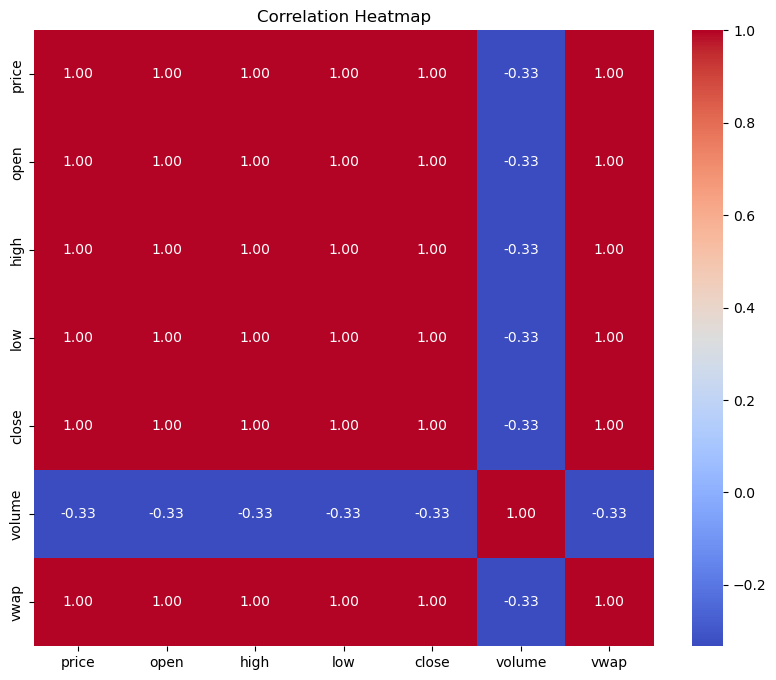

Highly Correlated Variable Pairs (|Correlation| > 0.9):
price - open: 1.00
price - high: 1.00
price - low: 1.00
price - close: 1.00
price - vwap: 1.00
open - high: 1.00
open - low: 1.00
open - close: 1.00
open - vwap: 1.00
high - low: 1.00
high - close: 1.00
high - vwap: 1.00
low - close: 1.00
low - vwap: 1.00
close - vwap: 1.00

Cleaned Dataset Overview:
                  time           timestamp      price   volume Symbol
0  2024-09-13T09:30:00 2024-09-13 13:30:00  223.04560  1588175   AAPL
1  2024-09-13T09:35:00 2024-09-13 13:35:00  222.78985   814140   AAPL
2  2024-09-13T09:40:00 2024-09-13 13:40:00  222.61500   556187   AAPL
3  2024-09-13T09:45:00 2024-09-13 13:45:00  222.49500   536019   AAPL
4  2024-09-13T09:50:00 2024-09-13 13:50:00  222.87000   879893   AAPL

Unique Variables dropped due to high correlation: ['close', 'high', 'low', 'open', 'vwap']


In [42]:
# Selecting only numerical columns for correlation analysis
numeric_cols = stock_data.select_dtypes(include=[np.number])

# Step 1: Compute the correlation matrix
correlation_matrix = numeric_cols.corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Step 2: Visualize the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Step 3: Detect highly correlated variables
threshold = 0.9  # Define a threshold for strong correlation
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            high_corr_pairs.append((col1, col2, correlation_matrix.iloc[i, j]))

# Display highly correlated pairs
print("Highly Correlated Variable Pairs (|Correlation| > 0.9):")
for pair in high_corr_pairs:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.2f}")

# Optional: Drop one of the variables in highly correlated pairs if needed
# Uncomment the below lines if you want to drop these variables
to_drop = set()  # Use a set to store unique variables to drop

for col1, col2, corr_value in high_corr_pairs:
    to_drop.add(col2)  # Add the second variable of each highly correlated pair

# Convert the set to a sorted list for better readability
to_drop = sorted(list(to_drop))

# Drop the highly correlated variables from the dataset
stock_data_cleaned = stock_data.drop(columns=to_drop)

print("\nCleaned Dataset Overview:")
print(stock_data_cleaned.head())

print("\nUnique Variables dropped due to high correlation:", to_drop)


#### Optional: Part 4: Additional Data Quality Issues
If the data and variables you are using have other quality issues, such as inconsistent date formats, incorrect data types (e.g., numbers stored as strings), or duplicate records, please address them.

In [69]:
# Convert 'time' to datetime format and adjust timezone if not already converted
if not isinstance(stock_data['time'].dtype, pd.DatetimeTZDtype):
    stock_data['time'] = pd.to_datetime(stock_data['time']).dt.tz_localize('US/Eastern')  # Assuming 'time' is in Eastern Time
else:
    stock_data['time'] = stock_data['time'].dt.tz_convert('US/Eastern')

# Convert 'timestamp' to datetime format and adjust timezone
if not isinstance(stock_data['timestamp'].dtype, pd.DatetimeTZDtype):
    stock_data['timestamp'] = pd.to_datetime(stock_data['timestamp']).dt.tz_localize('UTC').dt.tz_convert('US/Eastern')
else:
    stock_data['timestamp'] = stock_data['timestamp'].dt.tz_convert('US/Eastern')

# Verify consistency
stock_data['time_match'] = stock_data['time'] == stock_data['timestamp']  # Check if times match

# Display mismatched rows if any
mismatched_rows = stock_data[~stock_data['time_match']]

print("Mismatched Rows (if any):")
print(mismatched_rows)


Mismatched Rows (if any):
Empty DataFrame
Columns: [time, timestamp, price, open, high, low, close, volume, vwap, Symbol, time_match]
Index: []


### <font color="Green"> Part 5: Documentation </font>

Please write at least one paragraph summarizing the issues in your dataset and how you addressed them during the data cleaning process. You can refer to the following points to complete your summary paragraph:

Initial Data Quality Issues

- What missing values did you find?
- Were there any outliers?
- Did you discover any highly correlated variables?
- Were there any other quality issues encountered in this dataset?


Cleaning Process

- How did you handle missing values and why?
- Did you address any outliers? If so, how?
- If applicable, which variables did you remove or combine due to high correlations?
- If applicable, how did you resolve other data quality issues (e.g., formatting inconsistencies, duplicates)?

Final Dataset Characteristics

- How many observations and variables remain after cleaning?
- Is the dataset you have cleaned now suitable for further analysis or modeling?

### Data Cleaning Summary
During the initial exploration of the stock dataset, several data quality issues were identified. Missing values were present in columns like price, volume, and vwap. Additionally, there were potential outliers in the price and volume columns, detected using the IQR method, which flagged extreme values beyond reasonable trading ranges. Highly correlated variables, such as price, open, high, low, close, and vwap, were also found, with correlation coefficients close to 1, indicating redundancy. Other quality issues included inconsistent date-time formats between the time and timestamp columns and duplicate records.

To address these issues, missing values were imputed based on the nature of the data: forward fill and backward fill methods were applied for sequential columns like price and vwap, while mean and median imputation were used for non-sequential variables. Outliers were handled by either removing them or truncating them to acceptable thresholds. Redundant variables, such as open, high, low, and close, were removed to avoid multicollinearity issues and simplify the dataset. The inconsistent date-time formats were standardized by converting both time and timestamp columns to a common timezone. Duplicate records were identified and dropped to ensure data integrity.

After cleaning, the dataset consisted of 32214 observations and 11 variables, retaining essential information for further analysis. The cleaned dataset is now free from missing values, outliers, and redundancies, making it suitable for advanced analytics or predictive modeling. The cleaning process has ensured that the data is accurate, consistent, and reliable for decision-making.